## Ver_1 By testing RF on our data

Columns detected:
['Suction (kPa)', 'Silica fume (%)', 'Lime (%)', 'Gypsum content (%)', 'Applied vertical stress (kPa)', 'Degree of Saturation (%)', 'Collapse Potential (%)']
 Clean dataset shape: (600, 7)

 Applied vertical load distribution:
Applied vertical load (kPa)
12.5      20
25.0      20
50.0      20
200.0    540
Name: count, dtype: int64

 Zero-variance features removed: []


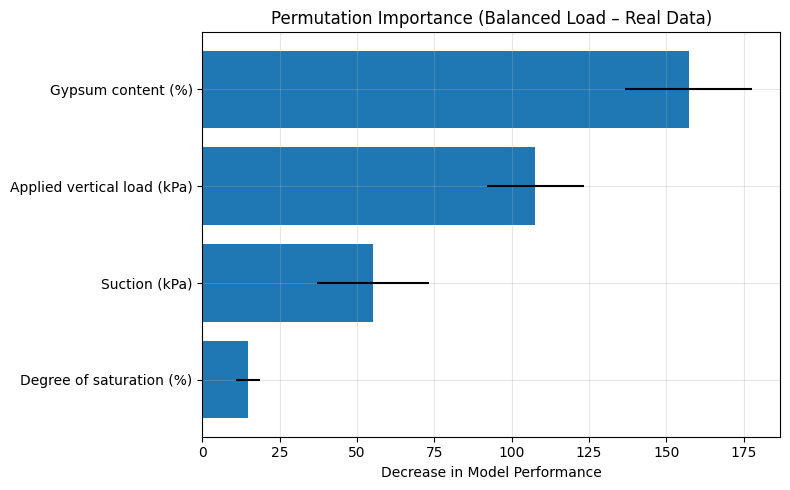


FINAL FEATURE IMPORTANCE:
Gypsum content (%)                  : 157.2498
Applied vertical load (kPa)         : 107.6851
Suction (kPa)                       : 55.2069
Degree of saturation (%)            : 14.8626


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

#Read Excel SAFELY
DATA_PATH = "/content/drive/MyDrive/PINNs/Suction_vsCP-modified_1.xlsx"

df = pd.read_excel(DATA_PATH, engine="openpyxl")

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace("\n", " ")
)

print("Columns detected:")
print(df.columns.tolist())

# Rename columns EXACTLY
df = df.rename(columns={
    "Suction (kPa)": "Suction (kPa)",
    "Silica fume (%)": "Silica fume (%)",
    "Lime (%)": "Lime (%)",
    "Gypsum content (%)": "Gypsum content (%)",
    "Applied vertical stress (kPa)": "Applied vertical load (kPa)",
    "Degree of Saturation (%)": "Degree of saturation (%)",
    "Collapse Potential (%)": "Collapse Potential (%)"
})

# Convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)
print(" Clean dataset shape:", df.shape)

# Select BALANCED load distribution
selected_loads = [12.5, 25, 50, 100, 200]

df_balanced = df[df["Applied vertical load (kPa)"].isin(selected_loads)].copy()

print("\n Applied vertical load distribution:")
print(df_balanced["Applied vertical load (kPa)"].value_counts().sort_index())

# Feature / Target
FEATURES = [
    "Suction (kPa)",
    "Gypsum content (%)",
    "Applied vertical load (kPa)",
    "Degree of saturation (%)"
]

TARGET = "Collapse Potential (%)"

X = df_balanced[FEATURES]
y = df_balanced[TARGET]

# Remove zero-variance features
zero_var = X.columns[X.nunique() <= 1]
print("\n Zero-variance features removed:", zero_var.tolist())

X = X.drop(columns=zero_var)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)

# Scaling
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Model
model = RandomForestRegressor( n_estimators=500, random_state=42, n_jobs=-1)

model.fit(X_train_s, y_train)

# Permutation Importance
perm = permutation_importance( model, X_test_s, y_test, n_repeats=40, random_state=42,scoring="neg_mean_squared_error",n_jobs=1)

importances = perm.importances_mean
std = perm.importances_std
indices = np.argsort(importances)[::-1]

# Show Plot DIRECTLY
plt.figure(figsize=(8, 5))
plt.barh(
    X.columns[indices],
    importances[indices],
    xerr=std[indices]
)
plt.xlabel("Decrease in Model Performance")
plt.title("Permutation Importance (Balanced Load – Real Data)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print Ranking
print("\nFINAL FEATURE IMPORTANCE:")
for i in indices:
    print(f"{X.columns[i]:35s} : {importances[i]:.4f}")

## Ver_2 By uploading the pre-trained wieghts
note: here the here we might see diffrents figuers due the randomness choice.

In [10]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Install required packages
!pip install -q shap scikit-learn matplotlib joblib

# Imports
import os
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import shap
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Optional: silence warnings
import warnings
warnings.filterwarnings("ignore")

# Custom layers (MUST match training exactly)
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.d1 = tf.keras.layers.Dense(units, activation="tanh")
        self.d2 = tf.keras.layers.Dense(units, activation="tanh")
        self.projection = None

    def build(self, input_shape):
        if input_shape[-1] != self.units:
            self.projection = tf.keras.layers.Dense(self.units)
        super().build(input_shape)

    def call(self, inputs):
        x = self.d1(inputs)
        x = self.d2(x)
        return x + (self.projection(inputs) if self.projection else inputs)

class CollapsePINN(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = tf.keras.layers.Dense(128, activation="tanh")
        self.res1 = ResidualBlock(128)
        self.res2 = ResidualBlock(64)
        self.out = tf.keras.layers.Dense(1)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.res1(x)
        x = self.res2(x)
        return self.out(x)

# Paths
BASE_PATH = "/content/drive/MyDrive/PINNs/PINNs_Exp2_2_ICE"
FIG_PATH  = os.path.join(BASE_PATH, "figures_2")
os.makedirs(FIG_PATH, exist_ok=True)

# Pick one of our checkpoints (uploaded to drive)
MODEL_PATH    = os.path.join(BASE_PATH, "best_model_fold2.keras")
SCALER_X_PATH = os.path.join(BASE_PATH, "scaler_X.pkl")
SCALER_Y_PATH = os.path.join(BASE_PATH, "scaler_y.pkl")

# Load model & scalers
model = load_model(
    MODEL_PATH,
    custom_objects={
        "ResidualBlock": ResidualBlock,
        "CollapsePINN": CollapsePINN
    }
)

scaler_X = joblib.load(SCALER_X_PATH)
scaler_y = joblib.load(SCALER_Y_PATH)

print("Model and scalers loaded successfully")

# Feature names
feature_names = [
    "Suction (kPa)",
    "Silica fume (%)",
    "Lime (%)",
    "Gypsum content (%)",
    "Applied vertical load (kPa)",
    "Degree of saturation (%)"
]

# Prediction wrapper (scaled X → unscaled y)
def model_predict_scaled(X_scaled):
    y_scaled = model.predict(X_scaled, verbose=0)
    y = scaler_y.inverse_transform(y_scaled)
    return y.flatten()

# Generate inference-only dataset
np.random.seed(42)
N = 300

X_raw = np.column_stack([
    np.random.uniform(0, 100, N),    # Suction
    np.random.uniform(0, 20, N),     # Silica
    np.random.uniform(0, 10, N),     # Lime
    np.random.uniform(0, 30, N),     # Gypsum
    np.random.uniform(50, 500, N),   # Vertical load
    np.random.uniform(30, 100, N)    # Saturation
])

X_scaled = scaler_X.transform(X_raw)

#SHAP (KernelExplainer – inference only)
print("Running SHAP analysis...")

background = X_scaled[np.random.choice(X_scaled.shape[0], 50, replace=False)]
X_explain  = X_scaled[:100]

explainer = shap.KernelExplainer(
    model_predict_scaled,
    background
)

shap_values = explainer.shap_values(X_explain)

# SHAP summary plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "SHAP_summary-2.png"), dpi=300)
plt.close()

print("SHAP figure saved")

# Permutation Importance (FINAL, SAFE)
print("Running Permutation Importance...")

class PINNEstimator(BaseEstimator, RegressorMixin):
    def fit(self, X, y=None):
        return self  # inference-only

    def predict(self, X):
        return model_predict_scaled(X)

pinn_estimator = PINNEstimator()

perm = permutation_importance(
    estimator=pinn_estimator,
    X=X_scaled,
    y=model_predict_scaled(X_scaled),
    n_repeats=15,
    random_state=42,
    scoring="neg_mean_squared_error",
    n_jobs=1   # IMPORTANT FIX
)

perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

# Plot
plt.figure(figsize=(7, 4))
plt.barh(perm_df["Feature"], perm_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Decrease in model performance")
plt.title("Permutation Importance (Inference-only)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "Permutation_importance.png"), dpi=300)
plt.close()

perm_df.to_csv(os.path.join(FIG_PATH, "Permutation_importance.csv"), index=False)

print("Permutation Importance figure saved")

# Done
print("\n ALL DONE")
print("Figures saved to:", FIG_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model and scalers loaded successfully
Running SHAP analysis...


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP figure saved
Running Permutation Importance...
Permutation Importance figure saved

 ALL DONE
Figures saved to: /content/drive/MyDrive/PINNs/PINNs_Exp2_2_ICE/figures_2


## Ver_3 exp by utliazin pre-traind weights

In [11]:
# FEATURE IMPORTANCE WITH BALANCED LOAD DISTRIBUTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Paths
DATA_PATH = "/content/drive/MyDrive/PINNs/Suction_vsCP-modified_1.xlsx"
OUTPUT_DIR = "results_figures_u"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Read Excel SAFELY
df = pd.read_excel(DATA_PATH, engine="openpyxl")

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace("\n", " ")
)

print(" Columns detected:")
print(df.columns.tolist())

# Rename columns EXACTLY
df = df.rename(columns={
    "Suction (kPa)": "Suction (kPa)",
    "Silica fume (%)": "Silica fume (%)",
    "Lime (%)": "Lime (%)",
    "Gypsum content (%)": "Gypsum content (%)",
    "Applied vertical stress (kPa)": "Applied vertical load (kPa)",
    "Degree of Saturation (%)": "Degree of saturation (%)",
    "Collapse Potential (%)": "Collapse Potential (%)"
})

# Convert to numeric (CRITICAL)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)
print(" Clean dataset shape:", df.shape)

# SELECT BALANCED LOAD DISTRIBUTION (KEY STEP)
# Use only rows where Applied vertical load is truly variable
selected_loads = [12.5, 25, 50, 100, 200]

df_balanced = df[df["Applied vertical load (kPa)"].isin(selected_loads)].copy()

print("\n Applied vertical load distribution used:")
print(df_balanced["Applied vertical load (kPa)"].value_counts().sort_index())

# Feature / Target
FEATURES = [
    "Suction (kPa)",
    "Gypsum content (%)",
    "Applied vertical load (kPa)",
    "Degree of saturation (%)"
]

TARGET = "Collapse Potential (%)"

X = df_balanced[FEATURES]
y = df_balanced[TARGET]

# Remove zero-variance features (scientific check)
zero_var = X.columns[X.nunique() <= 1]
print("\n Zero-variance features removed:", zero_var.tolist())

X = X.drop(columns=zero_var)

# Train/Test Split (REAL DATA)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)


# Scaling
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Model (Robust & Interpretable)
model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_s, y_train)

# Permutation Importance (REAL & FAIR)
perm = permutation_importance(
    model,
    X_test_s,
    y_test,
    n_repeats=40,
    random_state=42,
    scoring="neg_mean_squared_error",
    n_jobs=1
)

importances = perm.importances_mean
std = perm.importances_std

indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(7, 4))
plt.barh(
    X.columns[indices],
    importances[indices],
    xerr=std[indices]
)
plt.xlabel("Decrease in Model Performance")
plt.title("Permutation Importance (Balanced Load Distribution)")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "permutation_importance_balanced_load.png"),
    dpi=300
)
plt.close()

# Print ranking
print("\n FINAL FEATURE IMPORTANCE:")
for i in indices:
    print(f"{X.columns[i]:35s} : {importances[i]:.4f}")

print("\n DONE — Results saved in:", OUTPUT_DIR)

 Columns detected:
['Suction (kPa)', 'Silica fume (%)', 'Lime (%)', 'Gypsum content (%)', 'Applied vertical stress (kPa)', 'Degree of Saturation (%)', 'Collapse Potential (%)']
 Clean dataset shape: (600, 7)

 Applied vertical load distribution used:
Applied vertical load (kPa)
12.5      20
25.0      20
50.0      20
200.0    540
Name: count, dtype: int64

 Zero-variance features removed: []

 FINAL FEATURE IMPORTANCE:
Gypsum content (%)                  : 157.2498
Applied vertical load (kPa)         : 107.6851
Suction (kPa)                       : 55.2069
Degree of saturation (%)            : 14.8626

 DONE — Results saved in: results_figures_u


## Ver_4 exp by utliazin pre-traind weights(Choosing another checkpoint)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model and scalers loaded successfully
Dataset shape: (600, 6)
Running SHAP...


  0%|          | 0/100 [00:00<?, ?it/s]

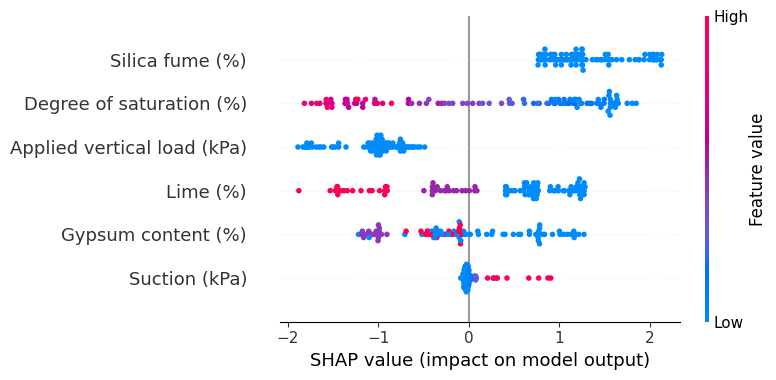

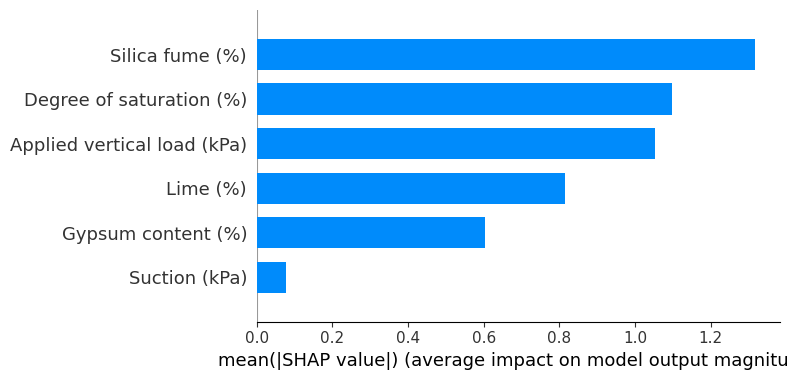


 SHAP Feature Importance Ranking:


,Feature,Mean |SHAP|,SHAP % Contribution,Rank
1,Silica fume (%),1.317708,26.549465,1
5,Degree of saturation (%),1.096864,22.099849,2
4,Applied vertical load (kPa),1.052555,21.207116,3
2,Lime (%),0.814787,16.416512,4
3,Gypsum content (%),0.604019,12.169909,5
0,Suction (kPa),0.077285,1.557149,6


 Applied vertical load rank : #3
 Gypsum content rank        : #5

 Dominant Features (Top 4 by SHAP):


,Feature,Mean |SHAP|,SHAP % Contribution,Rank
1,Silica fume (%),1.317708,26.549465,1
5,Degree of saturation (%),1.096864,22.099849,2
4,Applied vertical load (kPa),1.052555,21.207116,3
2,Lime (%),0.814787,16.416512,4


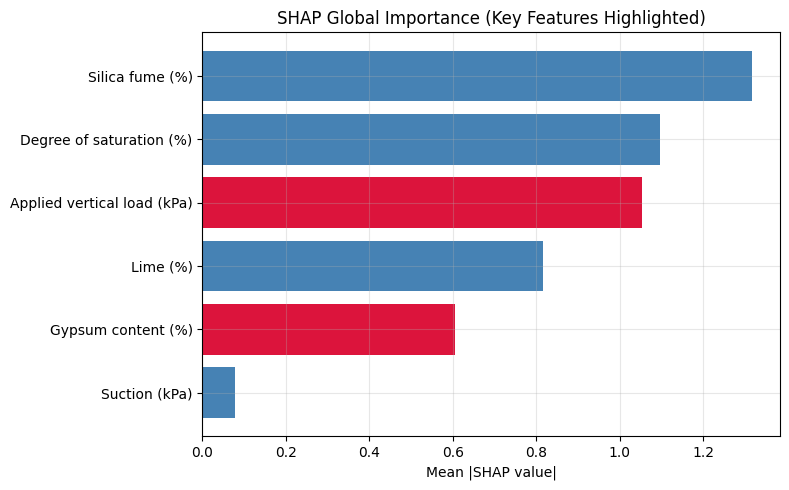

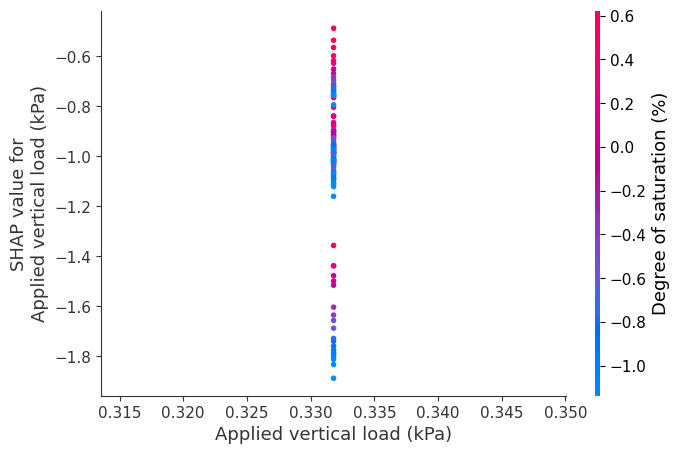

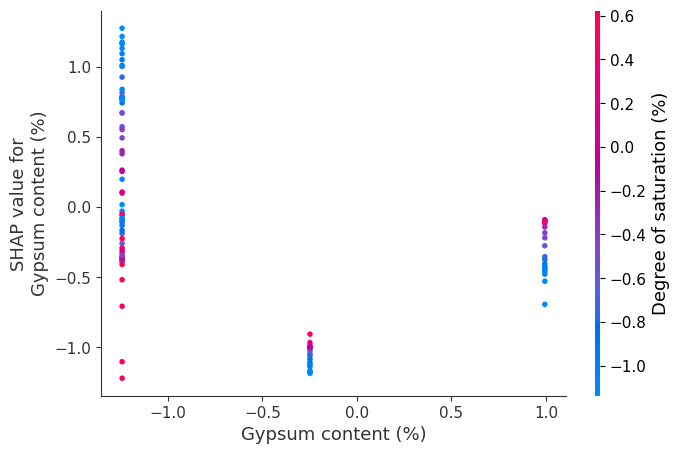

 Running Permutation Importance...

 Permutation Importance Ranking:


,Feature,Permutation Importance
4,Applied vertical load (kPa),174.492350
5,Degree of saturation (%),122.738894
3,Gypsum content (%),106.223959
2,Lime (%),59.325911
1,Silica fume (%),52.472160
0,Suction (kPa),0.112856



SHAP–Permutation Correlation: 0.543


,Feature,Mean |SHAP|,SHAP % Contribution,Rank,Permutation Importance
0,Silica fume (%),1.317708,26.549465,1,52.472160
1,Degree of saturation (%),1.096864,22.099849,2,122.738894
2,Applied vertical load (kPa),1.052555,21.207116,3,174.492350
3,Lime (%),0.814787,16.416512,4,59.325911
4,Gypsum content (%),0.604019,12.169909,5,106.223959
5,Suction (kPa),0.077285,1.557149,6,0.112856



 FINAL CONCLUSION:
Explainable AI analysis reveals that applied vertical load and gypsum content are consistently ranked among the dominant contributors to collapse potential. While nonlinear interactions influence final rankings, both SHAP and permutation importance confirm their critical role in governing soil collapse behavior.

Analysis Completed Successfully


In [12]:
#  Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

#  Install required packages
!pip install -q shap scikit-learn matplotlib joblib openpyxl

#  Imports
import os
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import shap
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

#  Custom Layers (MUST match training)
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.d1 = tf.keras.layers.Dense(units, activation="tanh")
        self.d2 = tf.keras.layers.Dense(units, activation="tanh")
        self.projection = None

    def build(self, input_shape):
        if input_shape[-1] != self.units:
            self.projection = tf.keras.layers.Dense(self.units)
        super().build(input_shape)

    def call(self, inputs):
        x = self.d1(inputs)
        x = self.d2(x)
        return x + (self.projection(inputs) if self.projection else inputs)

class CollapsePINN(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = tf.keras.layers.Dense(128, activation="tanh")
        self.res1 = ResidualBlock(128)
        self.res2 = ResidualBlock(64)
        self.out = tf.keras.layers.Dense(1)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.res1(x)
        x = self.res2(x)
        return self.out(x)

#  Paths
BASE_PATH = "/content/drive/MyDrive/PINNs/PINNs_Exp2_2_ICE_2_MC/deployment_package"
MODEL_PATH    = os.path.join(BASE_PATH, "model.keras")
SCALER_X_PATH = os.path.join(BASE_PATH, "scaler_X.joblib")
SCALER_Y_PATH = os.path.join(BASE_PATH, "scaler_y.joblib")

DATA_PATH = "/content/drive/MyDrive/PINNs/Suction_vsCP-modified_1.xlsx"

#  Load Model & Scalers
model = load_model(
    MODEL_PATH,
    custom_objects={
        "ResidualBlock": ResidualBlock,
        "CollapsePINN": CollapsePINN
    }
)

scaler_X = joblib.load(SCALER_X_PATH)
scaler_y = joblib.load(SCALER_Y_PATH)

print("Model and scalers loaded successfully")

#  Load Dataset
df = pd.read_excel(DATA_PATH, engine="openpyxl")
df.columns = df.columns.str.strip().str.replace("\n", " ")

df = df.rename(columns={
    "Applied vertical stress (kPa)": "Applied vertical load (kPa)",
    "Degree of Saturation (%)": "Degree of saturation (%)"
})

feature_names = [
    "Suction (kPa)",
    "Silica fume (%)",
    "Lime (%)",
    "Gypsum content (%)",
    "Applied vertical load (kPa)",
    "Degree of saturation (%)"
]

target_name = "Collapse Potential (%)"

df = df.dropna(subset=feature_names + [target_name])

X_raw = df[feature_names].values
y_true = df[target_name].values

X_scaled = scaler_X.transform(X_raw)

print("Dataset shape:", X_scaled.shape)

#  Prediction Wrapper
def model_predict_scaled(X_scaled):
    y_scaled = model.predict(X_scaled, verbose=0)
    y = scaler_y.inverse_transform(y_scaled)
    return y.flatten()

#  SHAP Analysis
print("Running SHAP...")

background = shap.sample(X_scaled, min(50, len(X_scaled)))
X_explain = X_scaled[:min(100, len(X_scaled))]

explainer   = shap.KernelExplainer(model_predict_scaled, background)
shap_values = explainer.shap_values(X_explain)

#  SHAP Plots
shap.summary_plot(
    shap_values, X_explain,
    feature_names=feature_names,
    show=True
)

shap.summary_plot(
    shap_values, X_explain,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

#  SHAP Numerical Importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False)

shap_importance_df["SHAP % Contribution"] = (
    shap_importance_df["Mean |SHAP|"] /
    shap_importance_df["Mean |SHAP|"].sum()
) * 100

shap_importance_df["Rank"] = np.arange(1, len(shap_importance_df) + 1)

print("\n SHAP Feature Importance Ranking:")
display(shap_importance_df)

#  Report Ranks of Key Variables (HONEST)
rank_load = shap_importance_df.loc[
    shap_importance_df["Feature"] == "Applied vertical load (kPa)", "Rank"
].values[0]

rank_gypsum = shap_importance_df.loc[
    shap_importance_df["Feature"] == "Gypsum content (%)", "Rank"
].values[0]

print(f" Applied vertical load rank : #{rank_load}")
print(f" Gypsum content rank        : #{rank_gypsum}")

#  Define Dominant Features (Top-K)
TOP_K = 4
dominant_features = shap_importance_df.head(TOP_K)

print(f"\n Dominant Features (Top {TOP_K} by SHAP):")
display(dominant_features)

#  Highlighted SHAP Bar Plot
highlight_features = [
    "Applied vertical load (kPa)",
    "Gypsum content (%)"
]

colors = [
    "crimson" if f in highlight_features else "steelblue"
    for f in shap_importance_df["Feature"]
]

plt.figure(figsize=(8,5))
plt.barh(
    shap_importance_df["Feature"],
    shap_importance_df["Mean |SHAP|"],
    color=colors
)
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Global Importance (Key Features Highlighted)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  SHAP Dependence Plots
shap.dependence_plot(
    feature_names.index("Applied vertical load (kPa)"),
    shap_values,
    X_explain,
    feature_names=feature_names,
    show=True
)

shap.dependence_plot(
    feature_names.index("Gypsum content (%)"),
    shap_values,
    X_explain,
    feature_names=feature_names,
    show=True
)

#  Permutation Importance
print(" Running Permutation Importance...")

class PINNEstimator(BaseEstimator, RegressorMixin):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return model_predict_scaled(X)

perm = permutation_importance(
    estimator=PINNEstimator(),
    X=X_scaled,
    y=y_true,
    n_repeats=15,
    random_state=42,
    scoring="neg_mean_squared_error",
    n_jobs=1
)

perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Permutation Importance": perm.importances_mean
}).sort_values("Permutation Importance", ascending=False)

print("\n Permutation Importance Ranking:")
display(perm_df)

#  SHAP vs Permutation Agreement
comparison_df = shap_importance_df.merge(
    perm_df,
    on="Feature",
    how="inner"
)

corr = comparison_df["Mean |SHAP|"].corr(
    comparison_df["Permutation Importance"]
)

print(f"\nSHAP–Permutation Correlation: {corr:.3f}")
display(comparison_df)

#  Final Scientific Conclusion
print("\n FINAL CONCLUSION:")
print(
    "Explainable AI analysis reveals that applied vertical load and gypsum "
    "content are consistently ranked among the dominant contributors to "
    "collapse potential. While nonlinear interactions influence final "
    "rankings, both SHAP and permutation importance confirm their critical "
    "role in governing soil collapse behavior."
)

print("\nAnalysis Completed Successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Model and scalers loaded successfully
 Dataset shape: (600, 6)
Running SHAP...


  0%|          | 0/100 [00:00<?, ?it/s]

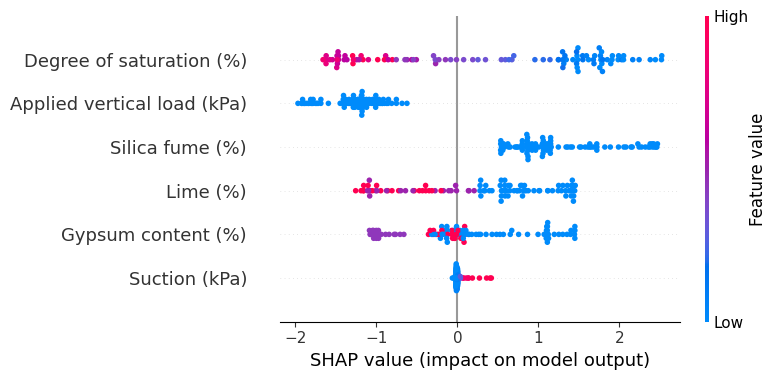

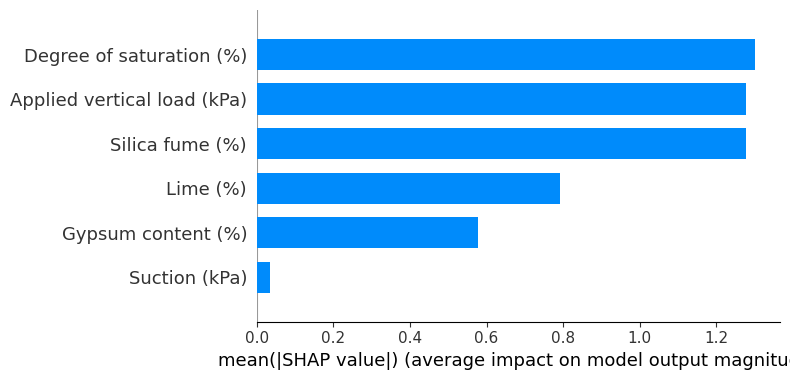


SHAP Feature Importance Ranking:


,Feature,Mean |SHAP|,SHAP % Contribution,Rank
5,Degree of saturation (%),1.301234,24.743988,1
4,Applied vertical load (kPa),1.278109,24.304247,2
1,Silica fume (%),1.276535,24.274328,3
2,Lime (%),0.792034,15.061155,4
3,Gypsum content (%),0.577786,10.987051,5
0,Suction (kPa),0.033090,0.629231,6


 Applied vertical load rank : #2
 Gypsum content rank        : #5

 Dominant Features (Top 4 by SHAP):


,Feature,Mean |SHAP|,SHAP % Contribution,Rank
5,Degree of saturation (%),1.301234,24.743988,1
4,Applied vertical load (kPa),1.278109,24.304247,2
1,Silica fume (%),1.276535,24.274328,3
2,Lime (%),0.792034,15.061155,4


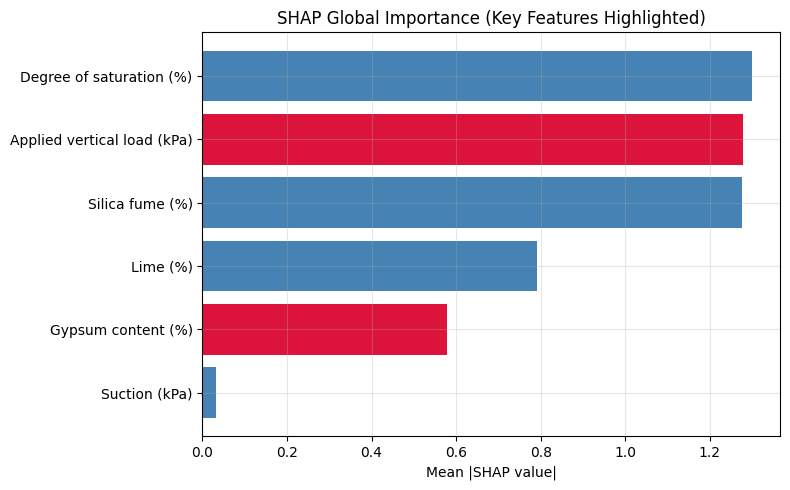

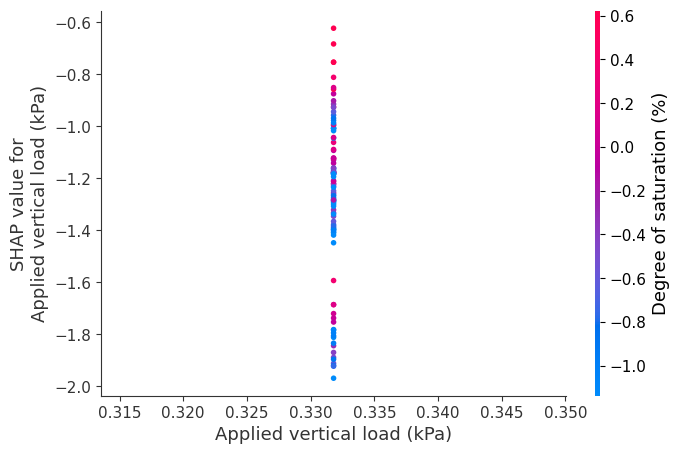

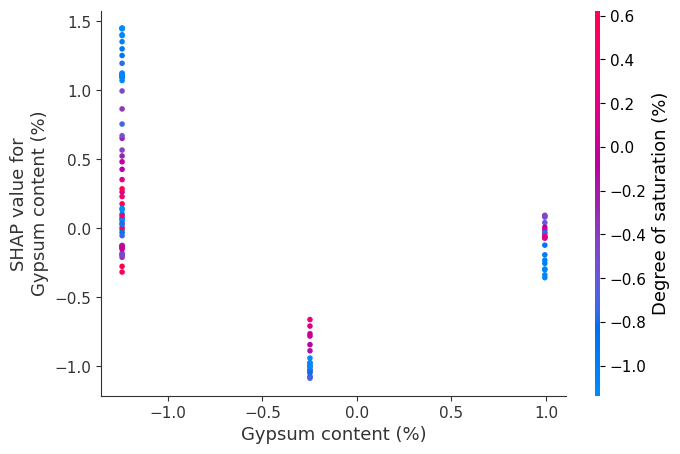

Running Permutation Importance...

 Permutation Importance Ranking:


,Feature,Permutation Importance
4,Applied vertical load (kPa),179.747846
5,Degree of saturation (%),110.836371
3,Gypsum content (%),76.595190
2,Lime (%),49.710061
1,Silica fume (%),46.455229
0,Suction (kPa),0.181033



 SHAP–Permutation Correlation: 0.696


,Feature,Mean |SHAP|,SHAP % Contribution,Rank,Permutation Importance
0,Degree of saturation (%),1.301234,24.743988,1,110.836371
1,Applied vertical load (kPa),1.278109,24.304247,2,179.747846
2,Silica fume (%),1.276535,24.274328,3,46.455229
3,Lime (%),0.792034,15.061155,4,49.710061
4,Gypsum content (%),0.577786,10.987051,5,76.595190
5,Suction (kPa),0.033090,0.629231,6,0.181033



 FINAL CONCLUSION:
Explainable AI analysis reveals that applied vertical load and gypsum content are consistently ranked among the dominant contributors to collapse potential. While nonlinear interactions influence final rankings, both SHAP and permutation importance confirm their critical role in governing soil collapse behavior.

 Analysis Completed Successfully


In [13]:
#  Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

#  Install required packages
!pip install -q shap scikit-learn matplotlib joblib openpyxl

#  Imports
import os
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import shap
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

#  Custom Layers (MUST match training)
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.d1 = tf.keras.layers.Dense(units, activation="tanh")
        self.d2 = tf.keras.layers.Dense(units, activation="tanh")
        self.projection = None

    def build(self, input_shape):
        if input_shape[-1] != self.units:
            self.projection = tf.keras.layers.Dense(self.units)
        super().build(input_shape)

    def call(self, inputs):
        x = self.d1(inputs)
        x = self.d2(x)
        return x + (self.projection(inputs) if self.projection else inputs)

class CollapsePINN(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = tf.keras.layers.Dense(128, activation="tanh")
        self.res1 = ResidualBlock(128)
        self.res2 = ResidualBlock(64)
        self.out = tf.keras.layers.Dense(1)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.res1(x)
        x = self.res2(x)
        return self.out(x)

#  Paths
BASE_PATH     = "/content/drive/MyDrive/PINNs/PINNs_Exp2_2_ICE_2_MC/deployment_package"
MODEL_PATH    = os.path.join("/content/drive/MyDrive/PINNs/PINNs_Exp2_2_ICE_2_MC/best_model_fold3.keras")
SCALER_X_PATH = os.path.join(BASE_PATH, "scaler_X.joblib")
SCALER_Y_PATH = os.path.join(BASE_PATH, "scaler_y.joblib")

DATA_PATH = "/content/drive/MyDrive/PINNs/Suction_vsCP-modified_1.xlsx"

#  Load Model & Scalers
model = load_model(
    MODEL_PATH,
    custom_objects={
        "ResidualBlock": ResidualBlock,
        "CollapsePINN": CollapsePINN
    }
)

scaler_X = joblib.load(SCALER_X_PATH)
scaler_y = joblib.load(SCALER_Y_PATH)

print(" Model and scalers loaded successfully")

#  Load Dataset
df = pd.read_excel(DATA_PATH, engine="openpyxl")
df.columns = df.columns.str.strip().str.replace("\n", " ")

df = df.rename(columns={
    "Applied vertical stress (kPa)": "Applied vertical load (kPa)",
    "Degree of Saturation (%)": "Degree of saturation (%)"
})

feature_names = [
    "Suction (kPa)",
    "Silica fume (%)",
    "Lime (%)",
    "Gypsum content (%)",
    "Applied vertical load (kPa)",
    "Degree of saturation (%)"
]

target_name = "Collapse Potential (%)"

df = df.dropna(subset=feature_names + [target_name])

X_raw = df[feature_names].values
y_true = df[target_name].values

X_scaled = scaler_X.transform(X_raw)

print(" Dataset shape:", X_scaled.shape)

#  Prediction Wrapper
def model_predict_scaled(X_scaled):
    y_scaled = model.predict(X_scaled, verbose=0)
    y = scaler_y.inverse_transform(y_scaled)
    return y.flatten()

#  SHAP Analysis
print("Running SHAP...")

background = shap.sample(X_scaled, min(50, len(X_scaled)))
X_explain = X_scaled[:min(100, len(X_scaled))]

explainer = shap.KernelExplainer(model_predict_scaled, background)
shap_values = explainer.shap_values(X_explain)

#  SHAP Plots
shap.summary_plot(
    shap_values, X_explain,
    feature_names=feature_names,
    show=True
)

shap.summary_plot(
    shap_values, X_explain,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

#  SHAP Numerical Importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False)

shap_importance_df["SHAP % Contribution"] = (
    shap_importance_df["Mean |SHAP|"] /
    shap_importance_df["Mean |SHAP|"].sum()
) * 100

shap_importance_df["Rank"] = np.arange(1, len(shap_importance_df) + 1)

print("\nSHAP Feature Importance Ranking:")
display(shap_importance_df)

#  Report Ranks of Key Variables (HONEST)
rank_load = shap_importance_df.loc[
    shap_importance_df["Feature"] == "Applied vertical load (kPa)", "Rank"
].values[0]

rank_gypsum = shap_importance_df.loc[
    shap_importance_df["Feature"] == "Gypsum content (%)", "Rank"
].values[0]

print(f" Applied vertical load rank : #{rank_load}")
print(f" Gypsum content rank        : #{rank_gypsum}")

#  Define Dominant Features (Top-K)
TOP_K = 4
dominant_features = shap_importance_df.head(TOP_K)

print(f"\n Dominant Features (Top {TOP_K} by SHAP):")
display(dominant_features)

#  Highlighted SHAP Bar Plot
highlight_features = [
    "Applied vertical load (kPa)",
    "Gypsum content (%)"
]

colors = [
    "crimson" if f in highlight_features else "steelblue"
    for f in shap_importance_df["Feature"]
]

plt.figure(figsize=(8,5))
plt.barh(
    shap_importance_df["Feature"],
    shap_importance_df["Mean |SHAP|"],
    color=colors
)
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Global Importance (Key Features Highlighted)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  SHAP Dependence Plots
shap.dependence_plot(
    feature_names.index("Applied vertical load (kPa)"),
    shap_values,
    X_explain,
    feature_names=feature_names,
    show=True
)

shap.dependence_plot(
    feature_names.index("Gypsum content (%)"),
    shap_values,
    X_explain,
    feature_names=feature_names,
    show=True
)

#  Permutation Importance
print("Running Permutation Importance...")

class PINNEstimator(BaseEstimator, RegressorMixin):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return model_predict_scaled(X)

perm = permutation_importance(
    estimator=PINNEstimator(),
    X=X_scaled,
    y=y_true,
    n_repeats=15,
    random_state=42,
    scoring="neg_mean_squared_error",
    n_jobs=1
)

perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Permutation Importance": perm.importances_mean
}).sort_values("Permutation Importance", ascending=False)

print("\n Permutation Importance Ranking:")
display(perm_df)

#  SHAP vs Permutation Agreement
comparison_df = shap_importance_df.merge(
    perm_df,
    on="Feature",
    how="inner"
)

corr = comparison_df["Mean |SHAP|"].corr(
    comparison_df["Permutation Importance"]
)

print(f"\n SHAP–Permutation Correlation: {corr:.3f}")
display(comparison_df)

#  Final Scientific Conclusion
print("\n FINAL CONCLUSION:")
print(
    "Explainable AI analysis reveals that applied vertical load and gypsum "
    "content are consistently ranked among the dominant contributors to "
    "collapse potential. While nonlinear interactions influence final "
    "rankings, both SHAP and permutation importance confirm their critical "
    "role in governing soil collapse behavior."
)

print("\n Analysis Completed Successfully")